# Supply Chain & Logistics Analytics
## DataCo Smart Supply Chain — Inventory, Delivery & Profitability Optimisation

**Objective:** Analyse 180,000+ supply chain transactions to uncover late delivery drivers, segment customers and products by profitability, identify underperforming markets and shipping modes, and deliver data-driven recommendations for inventory and logistics optimisation.

**Dataset:** DataCo Supply Chain Dataset · 180,519 orders · 53 features · 5 global markets  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

PALETTE = ['#2D6A9F','#E74C3C','#3BAB6F','#F39C12','#9B59B6','#1ABC9C','#E8834D','#34495E']
MARKET_COLORS = {
    'LATAM':'#E74C3C','Europe':'#2D6A9F','Pacific Asia':'#3BAB6F',
    'USCA':'#F39C12','Africa':'#9B59B6'
}
STATUS_COLORS = {
    'Late delivery':'#E74C3C','Shipping on time':'#3BAB6F',
    'Advance shipping':'#2D6A9F','Shipping canceled':'#95A5A6'
}

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['ship_date']  = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late'] = (df['Delivery Status'] == 'Late delivery').astype(int)
df['Year']  = df['order_date'].dt.year
df['Month'] = df['order_date'].dt.to_period('M')

print(f"Dataset: {df.shape[0]:,} orders x {df.shape[1]} features")
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Markets: {sorted(df['Market'].unique())}")
print(f"Late delivery rate: {df['is_late'].mean()*100:.1f}%")
df.head(3)


Dataset: 180,519 orders x 59 features
Date range: 2015-01-01 → 2018-01-31
Markets: ['Africa', 'Europe', 'LATAM', 'Pacific Asia', 'USCA']
Late delivery rate: 54.8%


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,order_date,ship_date,shipping_delay,is_late,Year,Month
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2/3/2018 22:56,Standard Class,2018-01-31 22:56:00,2018-02-03 22:56:00,-1,0,2018,2018-01
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0,1/18/2018 12:27,Standard Class,2018-01-13 12:27:00,2018-01-18 12:27:00,1,1,2018,2018-01
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0,1/17/2018 12:06,Standard Class,2018-01-13 12:06:00,2018-01-17 12:06:00,0,0,2018,2018-01


## 2. Exploratory Data Analysis

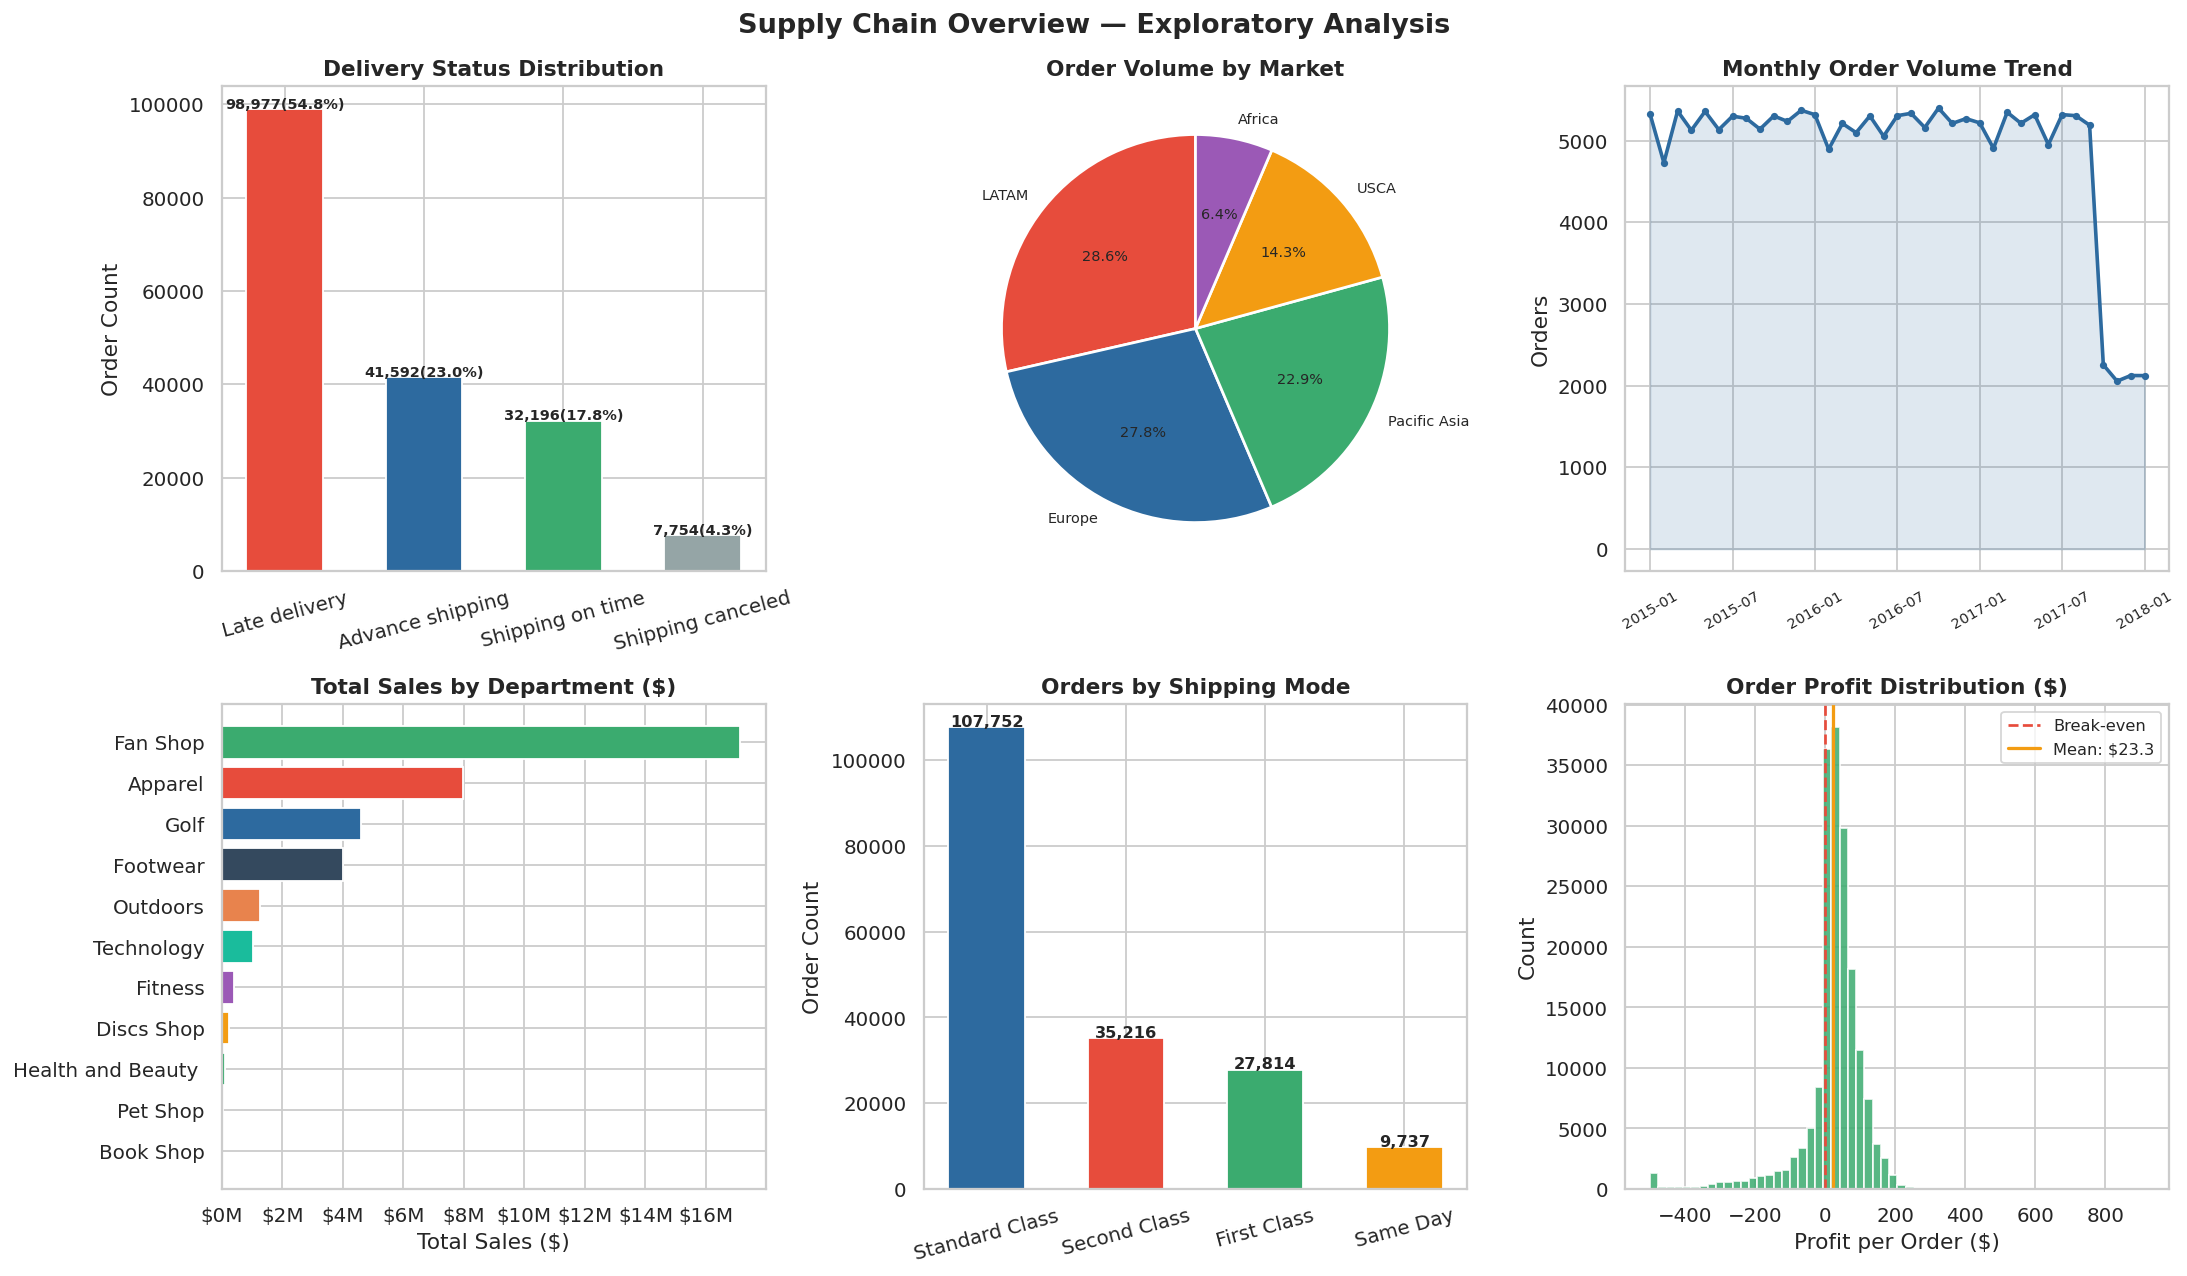

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Supply Chain Overview — Exploratory Analysis', fontsize=15, fontweight='bold')

# Delivery status distribution
ax = axes[0,0]
ds = df['Delivery Status'].value_counts()
bars = ax.bar(ds.index, ds.values,
              color=[STATUS_COLORS.get(s,'#95A5A6') for s in ds.index],
              width=0.55, edgecolor='white')
ax.set_title('Delivery Status Distribution', fontweight='bold')
ax.set_ylabel('Order Count')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, ds.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}({val/len(df)*100:.1f}%)', ha='center', fontsize=8, fontweight='bold')

# Orders by market
ax = axes[0,1]
mkt = df['Market'].value_counts()
wedges, texts, autotexts = ax.pie(
    mkt.values, labels=mkt.index,
    colors=[MARKET_COLORS.get(m,'#95A5A6') for m in mkt.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
[t.set_fontsize(8) for t in texts+autotexts]
ax.set_title('Order Volume by Market', fontweight='bold')

# Monthly order volume trend
ax = axes[0,2]
monthly = df.groupby('Month').size()
monthly.index = monthly.index.astype(str)
ax.plot(range(len(monthly)), monthly.values, color='#2D6A9F', linewidth=2, marker='o', markersize=3)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#2D6A9F')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels(monthly.index[::6], rotation=30, fontsize=8)
ax.set_title('Monthly Order Volume Trend', fontweight='bold')
ax.set_ylabel('Orders')

# Sales by department
ax = axes[1,0]
dept_sales = df.groupby('Department Name')['Sales'].sum().sort_values(ascending=False)
bars = ax.barh(dept_sales.index[::-1], dept_sales.values[::-1],
               color=PALETTE[:len(dept_sales)], edgecolor='white')
ax.set_title('Total Sales by Department ($)', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

# Shipping mode distribution
ax = axes[1,1]
sm = df['Shipping Mode'].value_counts()
bars = ax.bar(sm.index, sm.values, color=PALETTE[:4], width=0.55, edgecolor='white')
ax.set_title('Orders by Shipping Mode', fontweight='bold')
ax.set_ylabel('Order Count')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, sm.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Profit distribution
ax = axes[1,2]
profit = df['Order Profit Per Order'].clip(-500, 1000)
ax.hist(profit, bins=60, color='#3BAB6F', edgecolor='white', alpha=0.85)
ax.axvline(0, color='#E74C3C', linestyle='--', linewidth=1.5, label='Break-even')
ax.axvline(profit.mean(), color='#F39C12', linestyle='-', linewidth=1.8,
           label=f'Mean: ${profit.mean():.1f}')
ax.set_title('Order Profit Distribution ($)', fontweight='bold')
ax.set_xlabel('Profit per Order ($)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()


## 3. Late Delivery Deep-Dive

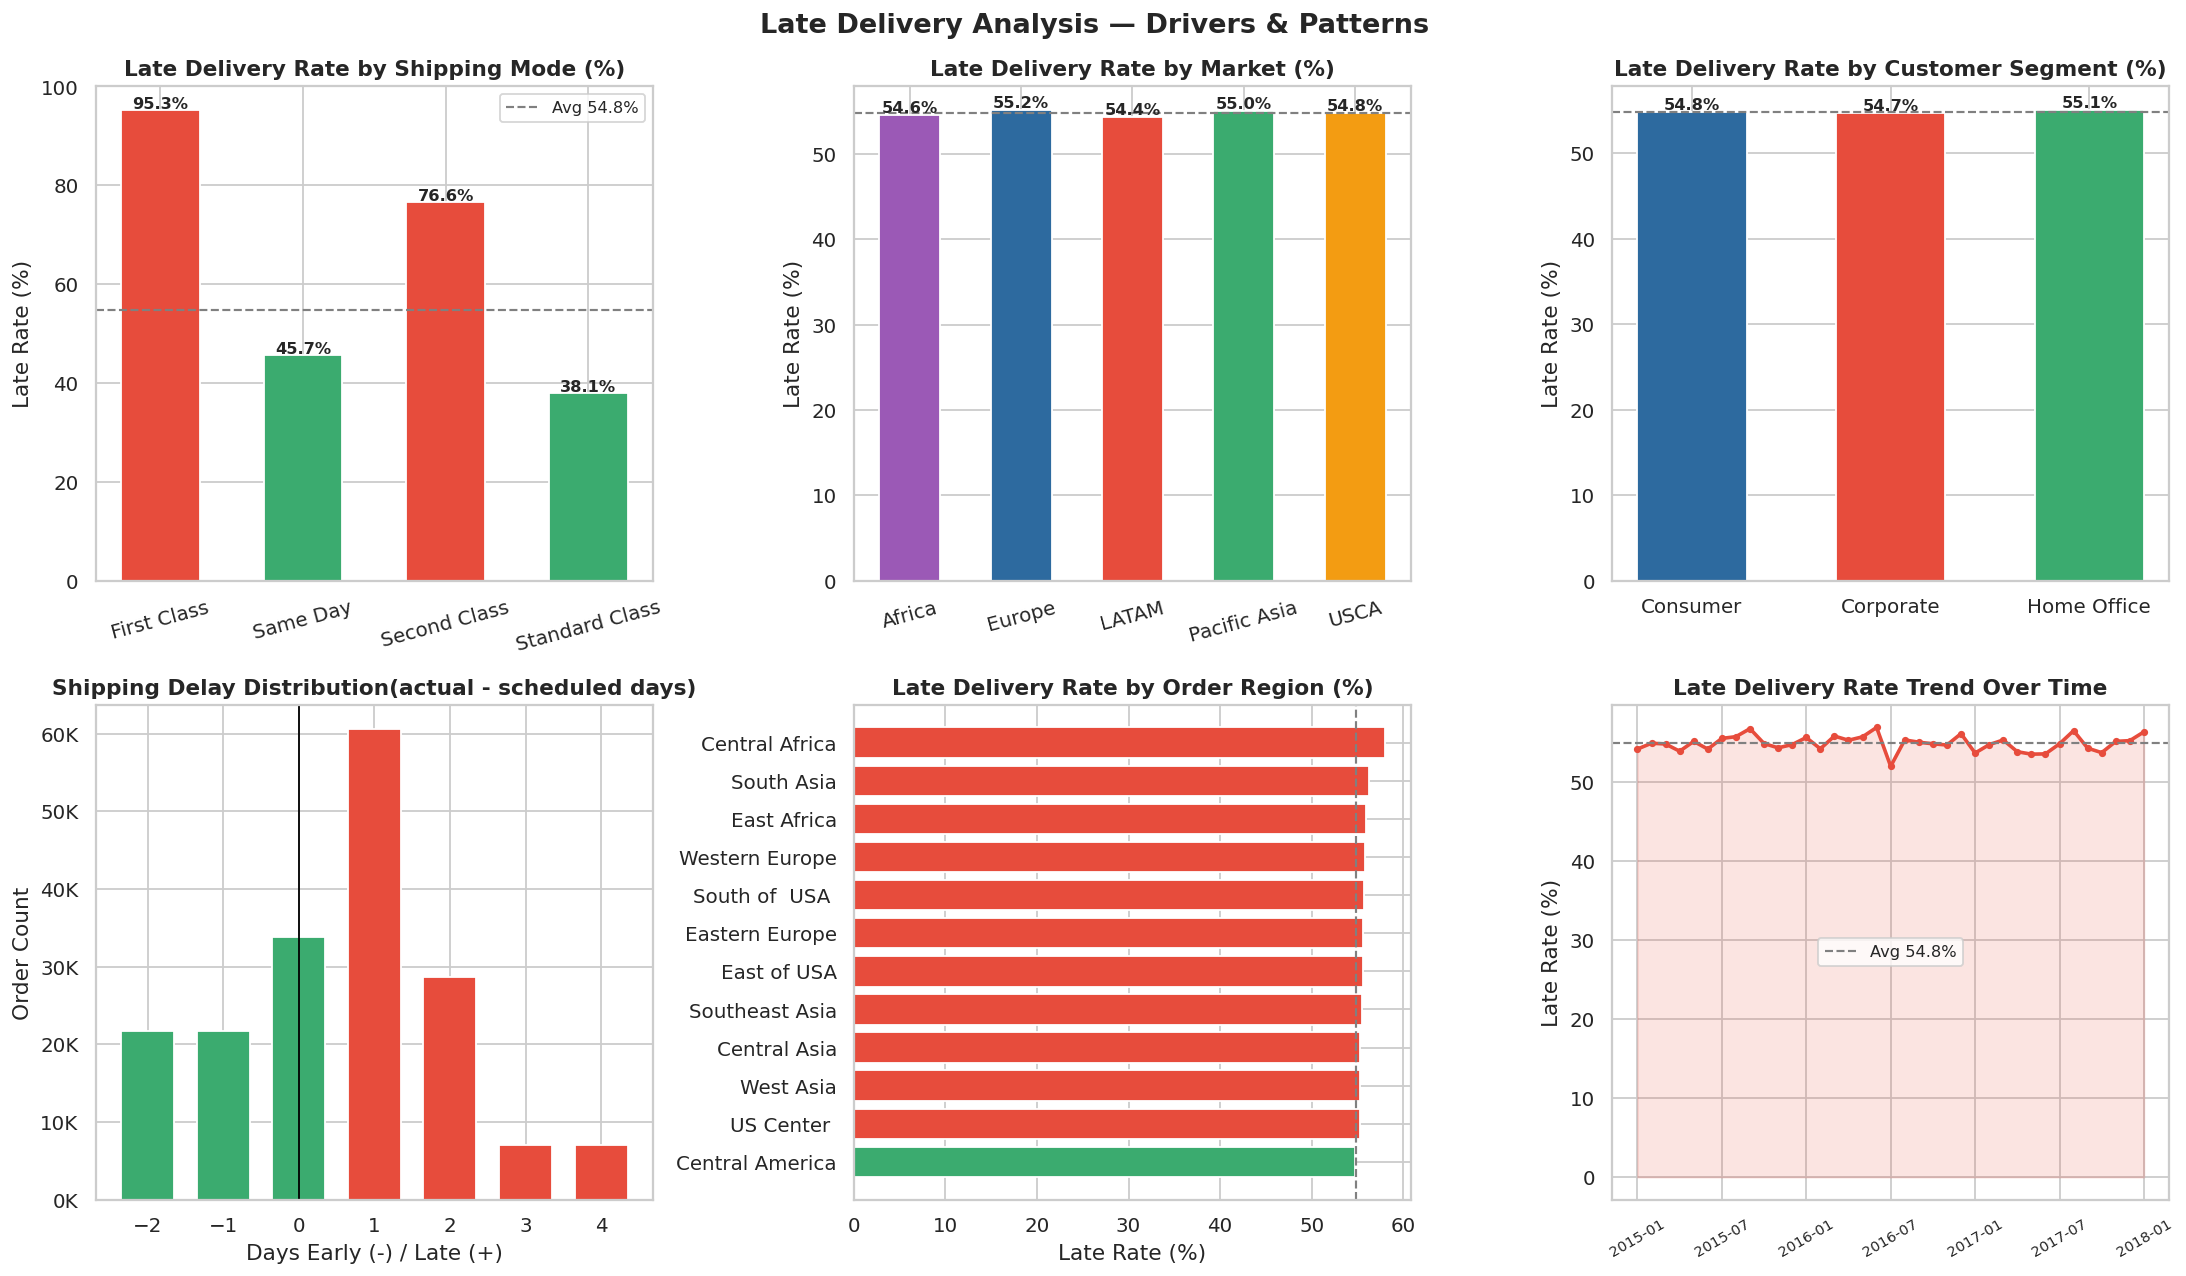

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Late Delivery Analysis — Drivers & Patterns', fontsize=15, fontweight='bold')

avg_late = df['is_late'].mean()*100

# Late rate by shipping mode
ax = axes[0,0]
late_sm = df.groupby('Shipping Mode')['is_late'].mean()*100
bars = ax.bar(late_sm.index, late_sm.values,
              color=['#E74C3C' if v > avg_late else '#3BAB6F' for v in late_sm.values],
              width=0.55, edgecolor='white')
ax.axhline(avg_late, color='gray', linestyle='--', linewidth=1.2, label=f'Avg {avg_late:.1f}%')
ax.set_title('Late Delivery Rate by Shipping Mode (%)', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Late rate by market
ax = axes[0,1]
late_mkt = df.groupby('Market')['is_late'].mean()*100
bars = ax.bar(late_mkt.index, late_mkt.values,
              color=[MARKET_COLORS.get(m,'#95A5A6') for m in late_mkt.index],
              width=0.55, edgecolor='white')
ax.axhline(avg_late, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Late Delivery Rate by Market (%)', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
ax.tick_params(axis='x', rotation=15)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Late rate by customer segment
ax = axes[0,2]
late_seg = df.groupby('Customer Segment')['is_late'].mean()*100
bars = ax.bar(late_seg.index, late_seg.values, color=PALETTE[:3], width=0.55, edgecolor='white')
ax.axhline(avg_late, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Late Delivery Rate by Customer Segment (%)', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Shipping delay distribution
ax = axes[1,0]
delay = df['shipping_delay'].value_counts().sort_index()
colors_d = ['#3BAB6F' if i <= 0 else '#E74C3C' for i in delay.index]
ax.bar(delay.index, delay.values, color=colors_d, edgecolor='white', width=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Shipping Delay Distribution(actual - scheduled days)', fontweight='bold')
ax.set_xlabel('Days Early (-) / Late (+)')
ax.set_ylabel('Order Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Late rate by top order regions
ax = axes[1,1]
late_region = df.groupby('Order Region')['is_late'].mean()*100
late_region = late_region.sort_values(ascending=False).head(12)
bar_colors = ['#E74C3C' if v > avg_late else '#3BAB6F' for v in late_region.values]
ax.barh(late_region.index[::-1], late_region.values[::-1], color=bar_colors[::-1], edgecolor='white')
ax.axvline(avg_late, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Late Delivery Rate by Order Region (%)', fontweight='bold')
ax.set_xlabel('Late Rate (%)')

# Late rate trend over time
ax = axes[1,2]
late_monthly = df.groupby('Month')['is_late'].mean()*100
late_monthly.index = late_monthly.index.astype(str)
ax.plot(range(len(late_monthly)), late_monthly.values,
        color='#E74C3C', linewidth=2, marker='o', markersize=3)
ax.fill_between(range(len(late_monthly)), late_monthly.values, alpha=0.15, color='#E74C3C')
ax.axhline(avg_late, color='gray', linestyle='--', linewidth=1.2, label=f'Avg {avg_late:.1f}%')
ax.set_xticks(range(0, len(late_monthly), 6))
ax.set_xticklabels(late_monthly.index[::6], rotation=30, fontsize=8)
ax.set_title('Late Delivery Rate Trend Over Time', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('late_delivery.png', bbox_inches='tight')
plt.show()


## 4. Profitability & Revenue Analysis

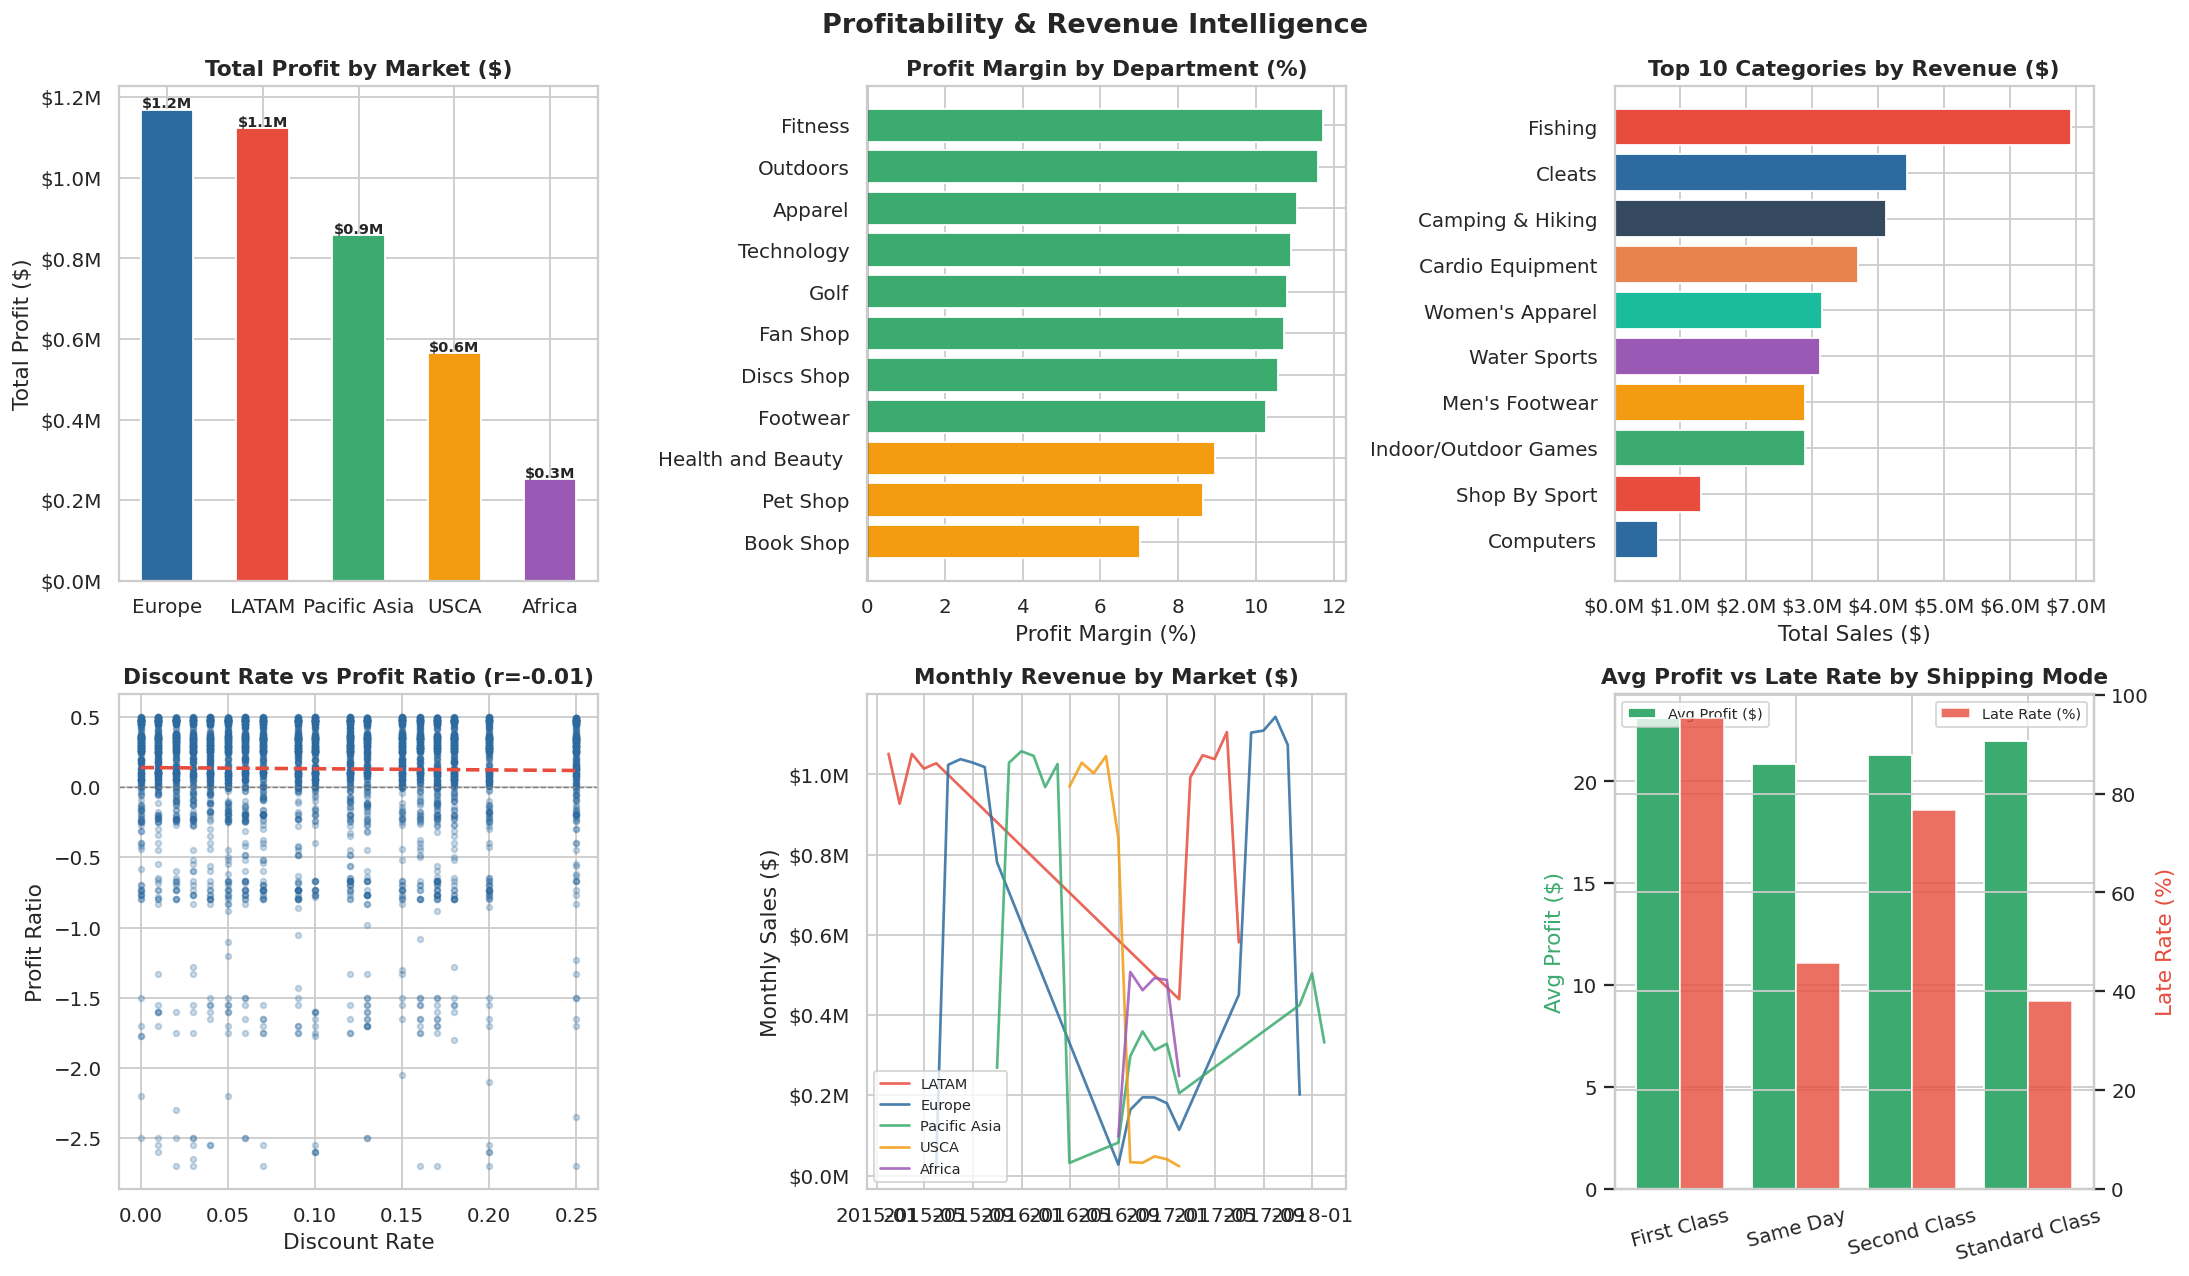

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Profitability & Revenue Intelligence', fontsize=15, fontweight='bold')

# Profit by market
ax = axes[0,0]
mkt_profit = df.groupby('Market').agg(
    Total_Profit=('Order Profit Per Order','sum'),
    Avg_Profit=('Order Profit Per Order','mean'),
    Orders=('Order Id','count')
).reset_index().sort_values('Total_Profit', ascending=False)
bars = ax.bar(mkt_profit['Market'], mkt_profit['Total_Profit'],
              color=[MARKET_COLORS.get(m,'#95A5A6') for m in mkt_profit['Market']],
              width=0.55, edgecolor='white')
ax.set_title('Total Profit by Market ($)', fontweight='bold')
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, mkt_profit['Total_Profit']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'${val/1e6:.1f}M', ha='center', fontsize=8, fontweight='bold')

# Profit margin by department
ax = axes[0,1]
dept_margin = df.groupby('Department Name').agg(
    Profit=('Order Profit Per Order','sum'),
    Sales=('Sales','sum')
).reset_index()
dept_margin['Margin'] = dept_margin['Profit']/dept_margin['Sales']*100
dept_margin = dept_margin.sort_values('Margin', ascending=True)
bar_colors_m = ['#E74C3C' if v < 0 else '#3BAB6F' if v > 10 else '#F39C12'
                for v in dept_margin['Margin']]
ax.barh(dept_margin['Department Name'], dept_margin['Margin'],
        color=bar_colors_m, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit Margin by Department (%)', fontweight='bold')
ax.set_xlabel('Profit Margin (%)')

# Top 10 product categories by revenue
ax = axes[0,2]
cat_sales = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)
short_labels = [c[:20]+'…' if len(c)>20 else c for c in cat_sales.index]
ax.barh(short_labels[::-1], cat_sales.values[::-1], color=PALETTE[:10], edgecolor='white')
ax.set_title('Top 10 Categories by Revenue ($)', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# Discount rate vs profit ratio scatter
ax = axes[1,0]
sample = df.sample(5000, random_state=42)
ax.scatter(sample['Order Item Discount Rate'], sample['Order Item Profit Ratio'],
           alpha=0.25, s=10, color='#2D6A9F')
m, b = np.polyfit(sample['Order Item Discount Rate'], sample['Order Item Profit Ratio'], 1)
x_line = np.linspace(0, sample['Order Item Discount Rate'].max(), 100)
ax.plot(x_line, m*x_line+b, color='#E74C3C', linewidth=2, linestyle='--')
corr = sample['Order Item Discount Rate'].corr(sample['Order Item Profit Ratio'])
ax.set_title(f'Discount Rate vs Profit Ratio (r={corr:.2f})', fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit Ratio')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Revenue trend by market over time
ax = axes[1,1]
mkt_monthly = df.groupby(['Market', pd.Grouper(key='order_date', freq='ME')])['Sales'].sum().reset_index()
for mkt, color in MARKET_COLORS.items():
    sub = mkt_monthly[mkt_monthly['Market']==mkt]
    ax.plot(sub['order_date'], sub['Sales'], color=color, linewidth=1.5, label=mkt, alpha=0.85)
ax.set_title('Monthly Revenue by Market ($)', fontweight='bold')
ax.set_ylabel('Monthly Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.legend(fontsize=8)

# Profit by shipping mode
ax = axes[1,2]
ship_profit = df.groupby('Shipping Mode').agg(
    Avg_Profit=('Order Profit Per Order','mean'),
    Late_Rate=('is_late','mean')
).reset_index()
x = np.arange(len(ship_profit)); w = 0.38
ax.bar(x-w/2, ship_profit['Avg_Profit'], w, label='Avg Profit ($)',
       color='#3BAB6F', edgecolor='white')
ax2s = ax.twinx()
ax2s.bar(x+w/2, ship_profit['Late_Rate']*100, w, label='Late Rate (%)',
         color='#E74C3C', edgecolor='white', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(ship_profit['Shipping Mode'], rotation=15)
ax.set_title('Avg Profit vs Late Rate by Shipping Mode', fontweight='bold')
ax.set_ylabel('Avg Profit ($)', color='#3BAB6F')
ax2s.set_ylabel('Late Rate (%)', color='#E74C3C')
ax.legend(loc='upper left', fontsize=8)
ax2s.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('profitability.png', bbox_inches='tight')
plt.show()


## 5. Customer & Order Segmentation

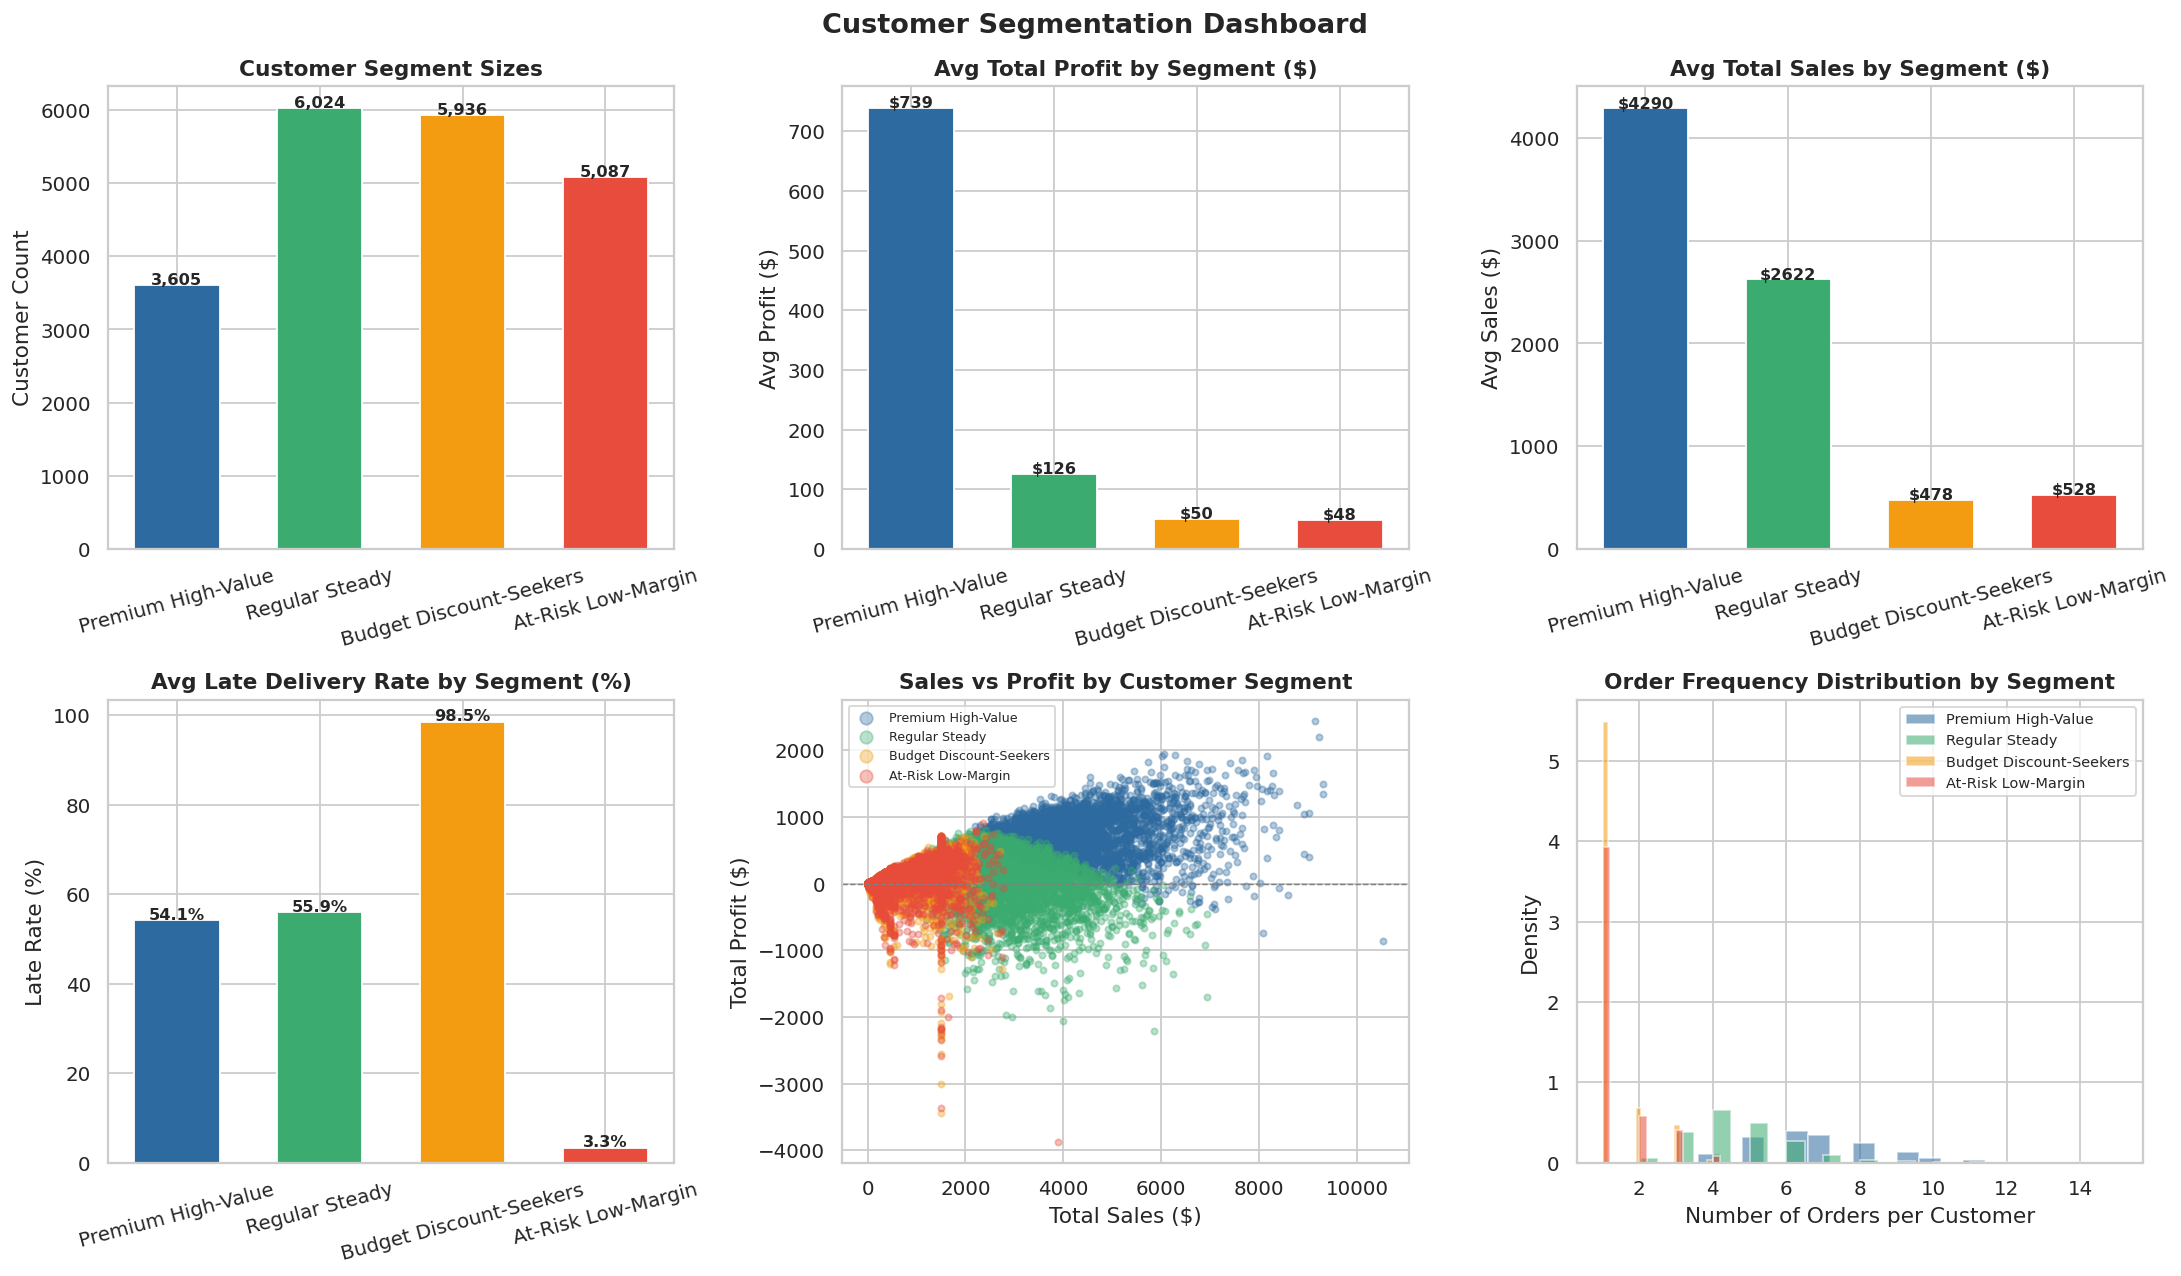

In [5]:
# Build customer-level RFM-style features
customer = df.groupby('Order Customer Id').agg(
    Orders      = ('Order Id','nunique'),
    Total_Sales = ('Sales','sum'),
    Total_Profit= ('Order Profit Per Order','sum'),
    Avg_Discount= ('Order Item Discount Rate','mean'),
    Late_Rate   = ('is_late','mean'),
    Avg_Quantity= ('Order Item Quantity','mean'),
).reset_index()

scaler = StandardScaler()
X_cust = scaler.fit_transform(customer[['Orders','Total_Sales','Total_Profit',
                                         'Avg_Discount','Late_Rate']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=15)
customer['Cluster'] = kmeans.fit_predict(X_cust)

profile = customer.groupby('Cluster').agg(
    Count=('Order Customer Id','count'),
    Avg_Orders=('Orders','mean'),
    Avg_Sales=('Total_Sales','mean'),
    Avg_Profit=('Total_Profit','mean'),
    Avg_Late=('Late_Rate','mean'),
).reset_index().sort_values('Avg_Profit', ascending=False).reset_index(drop=True)

seg_names = ['Premium High-Value','Regular Steady','Budget Discount-Seekers','At-Risk Low-Margin']
profile['Segment'] = seg_names
cid_to_name = dict(zip(profile['Cluster'], profile['Segment']))
customer['Segment'] = customer['Cluster'].map(cid_to_name)
seg_colors = ['#2D6A9F','#3BAB6F','#F39C12','#E74C3C']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Customer Segmentation Dashboard', fontsize=15, fontweight='bold')

# Segment sizes
ax = axes[0,0]
bars = ax.bar(seg_names, profile['Count'], color=seg_colors, width=0.6, edgecolor='white')
ax.set_title('Customer Segment Sizes', fontweight='bold')
ax.set_ylabel('Customer Count')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profile['Count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Avg profit by segment
ax = axes[0,1]
bars = ax.bar(seg_names, profile['Avg_Profit'], color=seg_colors, width=0.6, edgecolor='white')
ax.set_title('Avg Total Profit by Segment ($)', fontweight='bold')
ax.set_ylabel('Avg Profit ($)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profile['Avg_Profit']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Avg sales by segment
ax = axes[0,2]
bars = ax.bar(seg_names, profile['Avg_Sales'], color=seg_colors, width=0.6, edgecolor='white')
ax.set_title('Avg Total Sales by Segment ($)', fontweight='bold')
ax.set_ylabel('Avg Sales ($)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profile['Avg_Sales']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Late rate by segment
ax = axes[1,0]
bars = ax.bar(seg_names, profile['Avg_Late']*100, color=seg_colors, width=0.6, edgecolor='white')
ax.set_title('Avg Late Delivery Rate by Segment (%)', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profile['Avg_Late']*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Sales vs profit scatter by segment
ax = axes[1,1]
for i, name in enumerate(seg_names):
    sub = customer[customer['Segment']==name]
    ax.scatter(sub['Total_Sales'], sub['Total_Profit'],
               color=seg_colors[i], alpha=0.35, s=12, label=name)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Sales vs Profit by Customer Segment', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Total Profit ($)')
ax.legend(fontsize=7, markerscale=2)

# Orders distribution by segment
ax = axes[1,2]
for i, name in enumerate(seg_names):
    sub = customer[customer['Segment']==name]['Orders']
    ax.hist(sub, bins=20, alpha=0.55, color=seg_colors[i], label=name, density=True)
ax.set_title('Order Frequency Distribution by Segment', fontweight='bold')
ax.set_xlabel('Number of Orders per Customer')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('customer_segments.png', bbox_inches='tight')
plt.show()


## 6. Late Delivery Prediction Model

In [6]:
le = LabelEncoder()
df_model = df.sample(50000, random_state=42).copy()

cat_cols = ['Market','Shipping Mode','Customer Segment','Department Name','Order Region']
for col in cat_cols:
    df_model[col+'_enc'] = le.fit_transform(df_model[col].astype(str))

feature_cols = [c+'_enc' for c in cat_cols] + [
    'Days for shipment (scheduled)','Order Item Quantity',
    'Order Item Discount Rate','Sales','Order Item Profit Ratio',
    'Order Item Product Price'
]

X = df_model[feature_cols]
y = df_model['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
scaler_m = StandardScaler()
X_train_sc = scaler_m.fit_transform(X_train)
X_test_sc  = scaler_m.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}
results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:,1]
    auc     = roc_auc_score(y_test, y_proba)
    cv_auc  = cross_val_score(model, scaler_m.transform(X), y, cv=5, scoring='roc_auc').mean()
    results[name] = {'model':model,'y_pred':y_pred,'y_proba':y_proba,'auc':auc,'cv_auc':cv_auc}
    print(f"{name:<25} | AUC: {auc:.4f} | CV AUC: {cv_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['On Time','Late'], digits=3))

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_name} (AUC={results[best_name]['auc']:.4f})")


Logistic Regression       | AUC: 0.7147 | CV AUC: 0.7129
              precision    recall  f1-score   support

     On Time      0.617     0.819     0.704      4512
        Late      0.796     0.582     0.673      5488

    accuracy                          0.689     10000
   macro avg      0.707     0.701     0.688     10000
weighted avg      0.715     0.689     0.687     10000



Random Forest             | AUC: 0.7156 | CV AUC: 0.7135
              precision    recall  f1-score   support

     On Time      0.606     0.669     0.636      4512
        Late      0.702     0.642     0.671      5488

    accuracy                          0.654     10000
   macro avg      0.654     0.656     0.653     10000
weighted avg      0.659     0.654     0.655     10000



Gradient Boosting         | AUC: 0.7271 | CV AUC: 0.7273
              precision    recall  f1-score   support

     On Time      0.612     0.871     0.719      4512
        Late      0.838     0.546     0.661      5488

    accuracy                          0.693     10000
   macro avg      0.725     0.709     0.690     10000
weighted avg      0.736     0.693     0.687     10000


Best model: Gradient Boosting (AUC=0.7271)


## 7. Model Evaluation & Supply Chain KPI Dashboard

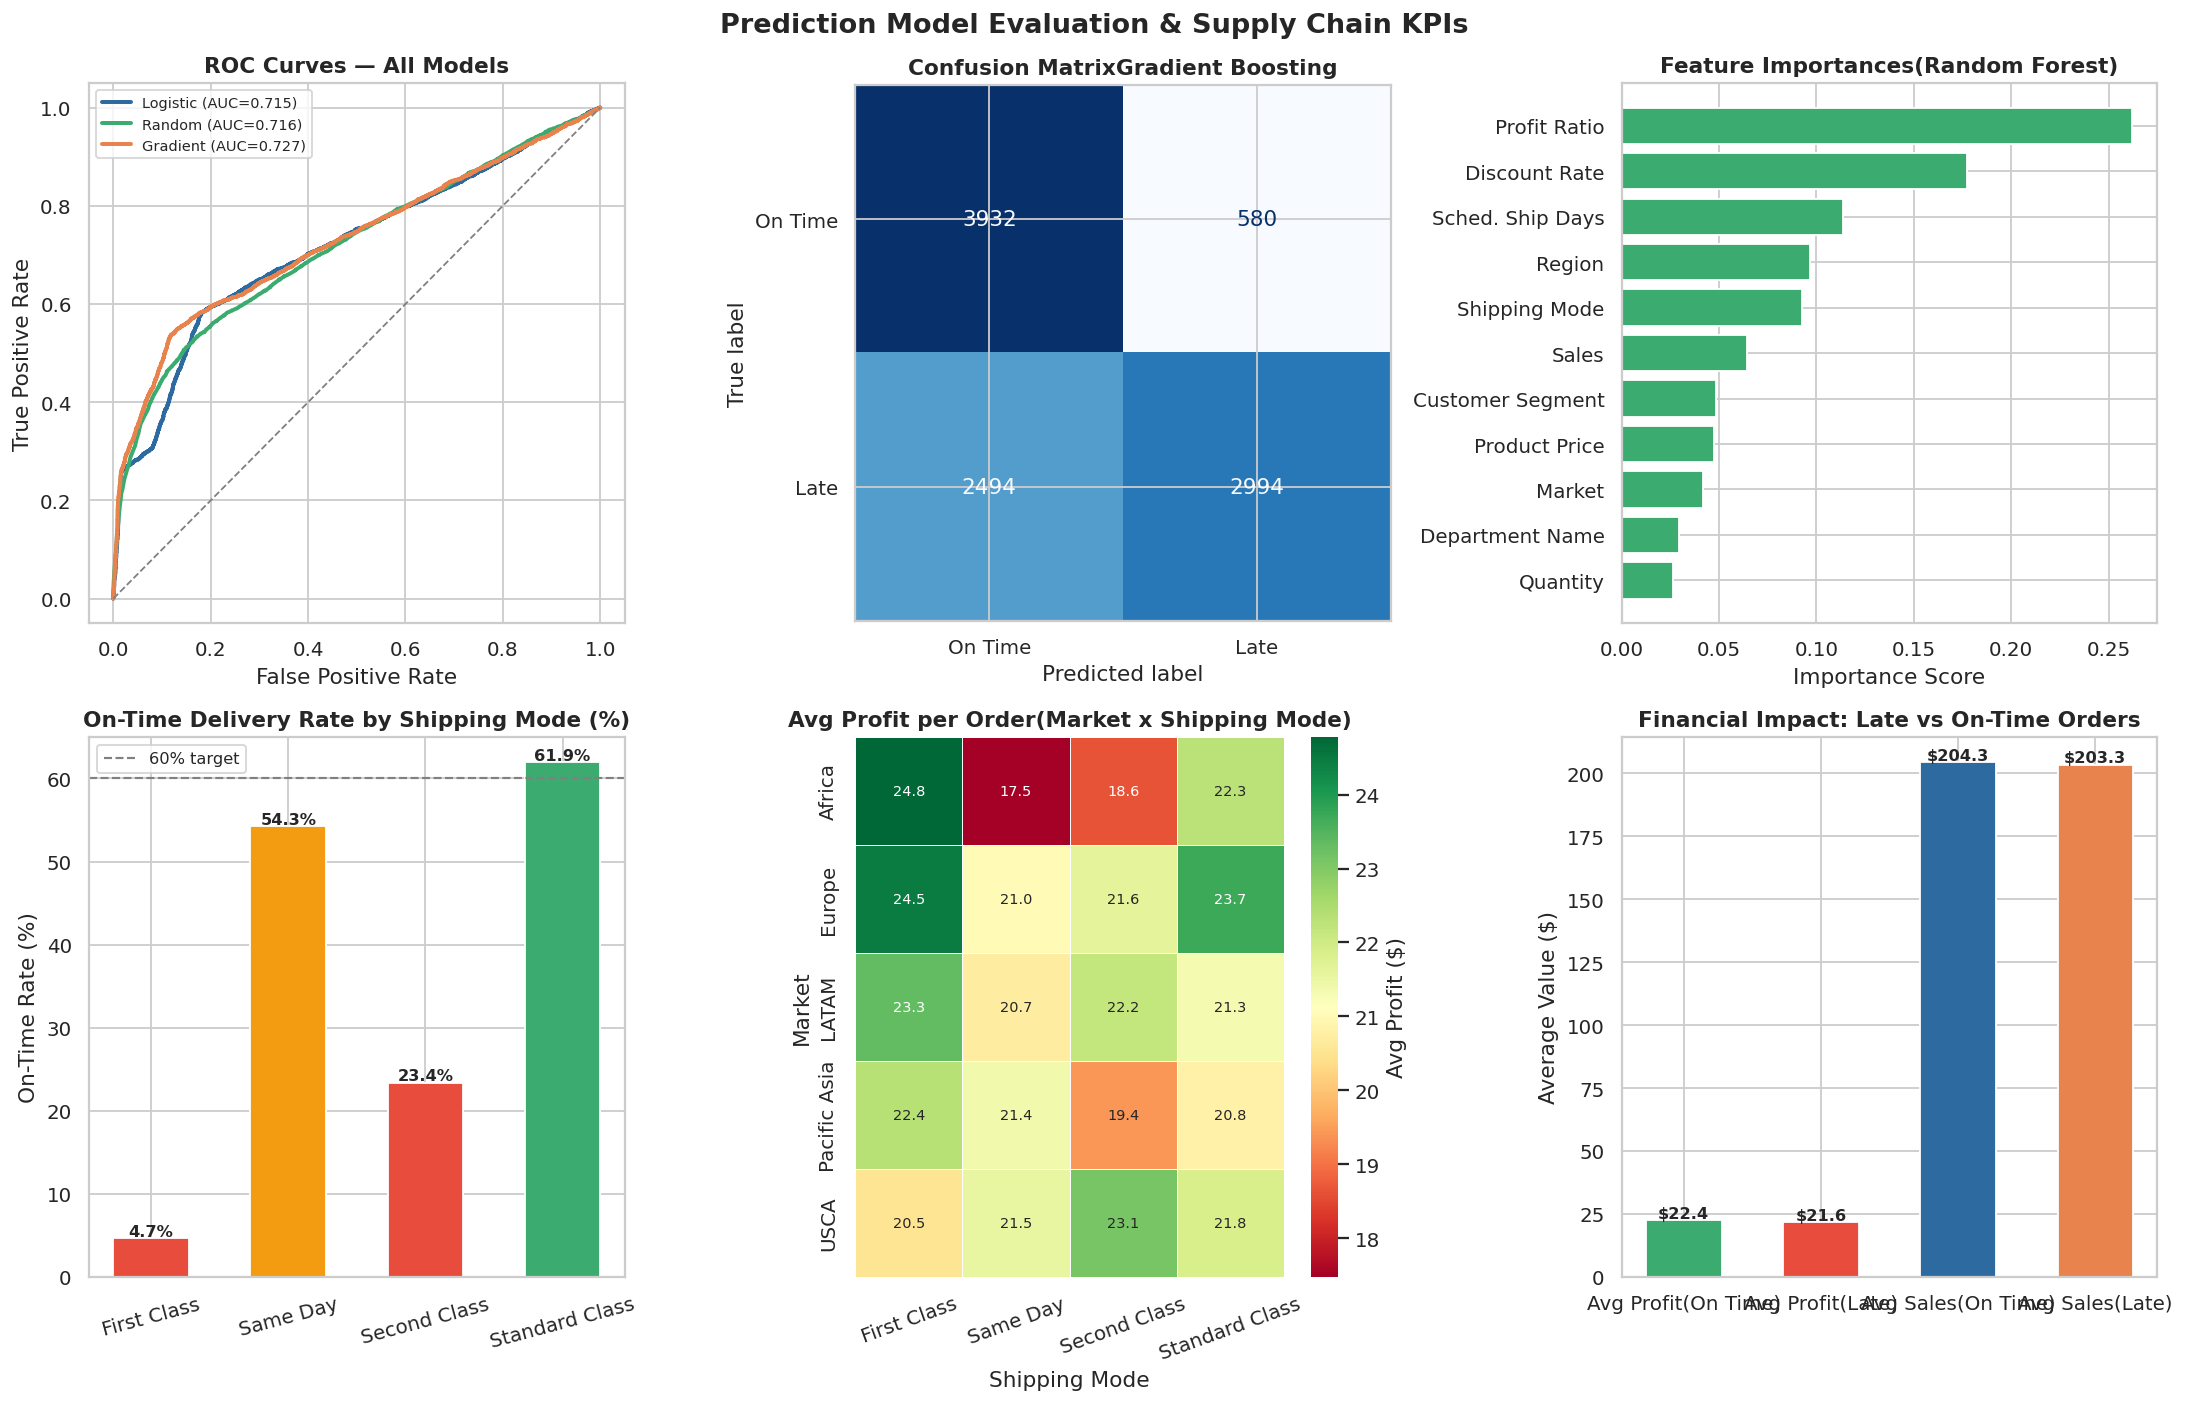

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Prediction Model Evaluation & Supply Chain KPIs', fontsize=15, fontweight='bold')

model_colors = ['#2D6A9F','#3BAB6F','#E8834D']
best_res = results[best_name]

# ROC curves
ax = axes[0,0]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=model_colors[i], linewidth=2.2,
            label=f"{name.split()[0]} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8)

# Confusion matrix
ax = axes[0,1]
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['On Time','Late'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix{best_name}', fontweight='bold')

# Feature importance
ax = axes[0,2]
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
clean_labels = [f.replace('_enc','').replace('Days for shipment (scheduled)','Sched. Ship Days')
                .replace('Order Item ','').replace('Order ','') for f in feat_imp.index]
bars = ax.barh(clean_labels[::-1], feat_imp.values[::-1], color='#3BAB6F', edgecolor='white')
ax.set_title('Feature Importances(Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')

# KPI 1: On-time delivery rate by shipping mode
ax = axes[1,0]
ontime = df.groupby('Shipping Mode')['is_late'].agg(['mean','count']).reset_index()
ontime['on_time_rate'] = (1 - ontime['mean'])*100
bars = ax.bar(ontime['Shipping Mode'], ontime['on_time_rate'],
              color=['#3BAB6F' if v >= 60 else '#F39C12' if v >= 50 else '#E74C3C'
                     for v in ontime['on_time_rate']],
              width=0.55, edgecolor='white')
ax.axhline(60, color='gray', linestyle='--', linewidth=1.2, label='60% target')
ax.set_title('On-Time Delivery Rate by Shipping Mode (%)', fontweight='bold')
ax.set_ylabel('On-Time Rate (%)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=15)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# KPI 2: Avg profit per order by market & shipping mode
ax = axes[1,1]
heat_data = df.groupby(['Market','Shipping Mode'])['Order Profit Per Order'].mean().unstack()
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Profit ($)'},
            annot_kws={'size':8})
ax.set_title('Avg Profit per Order(Market x Shipping Mode)', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# KPI 3: Late delivery cost impact
ax = axes[1,2]
late_orders  = df[df['is_late']==1]
ontime_orders= df[df['is_late']==0]
metrics = {
    'Avg Profit(On Time)':  ontime_orders['Order Profit Per Order'].mean(),
    'Avg Profit(Late)':     late_orders['Order Profit Per Order'].mean(),
    'Avg Sales(On Time)':   ontime_orders['Sales'].mean(),
    'Avg Sales(Late)':      late_orders['Sales'].mean(),
}
colors_k = ['#3BAB6F','#E74C3C','#2D6A9F','#E8834D']
bars = ax.bar(metrics.keys(), metrics.values(), color=colors_k, width=0.55, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Financial Impact: Late vs On-Time Orders', fontweight='bold')
ax.set_ylabel('Average Value ($)')
for bar, val in zip(bars, metrics.values()):
    offset = 1 if val >= 0 else -5
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
            f'${val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_kpis.png', bbox_inches='tight')
plt.show()


## 8. Inventory & Operational Insights

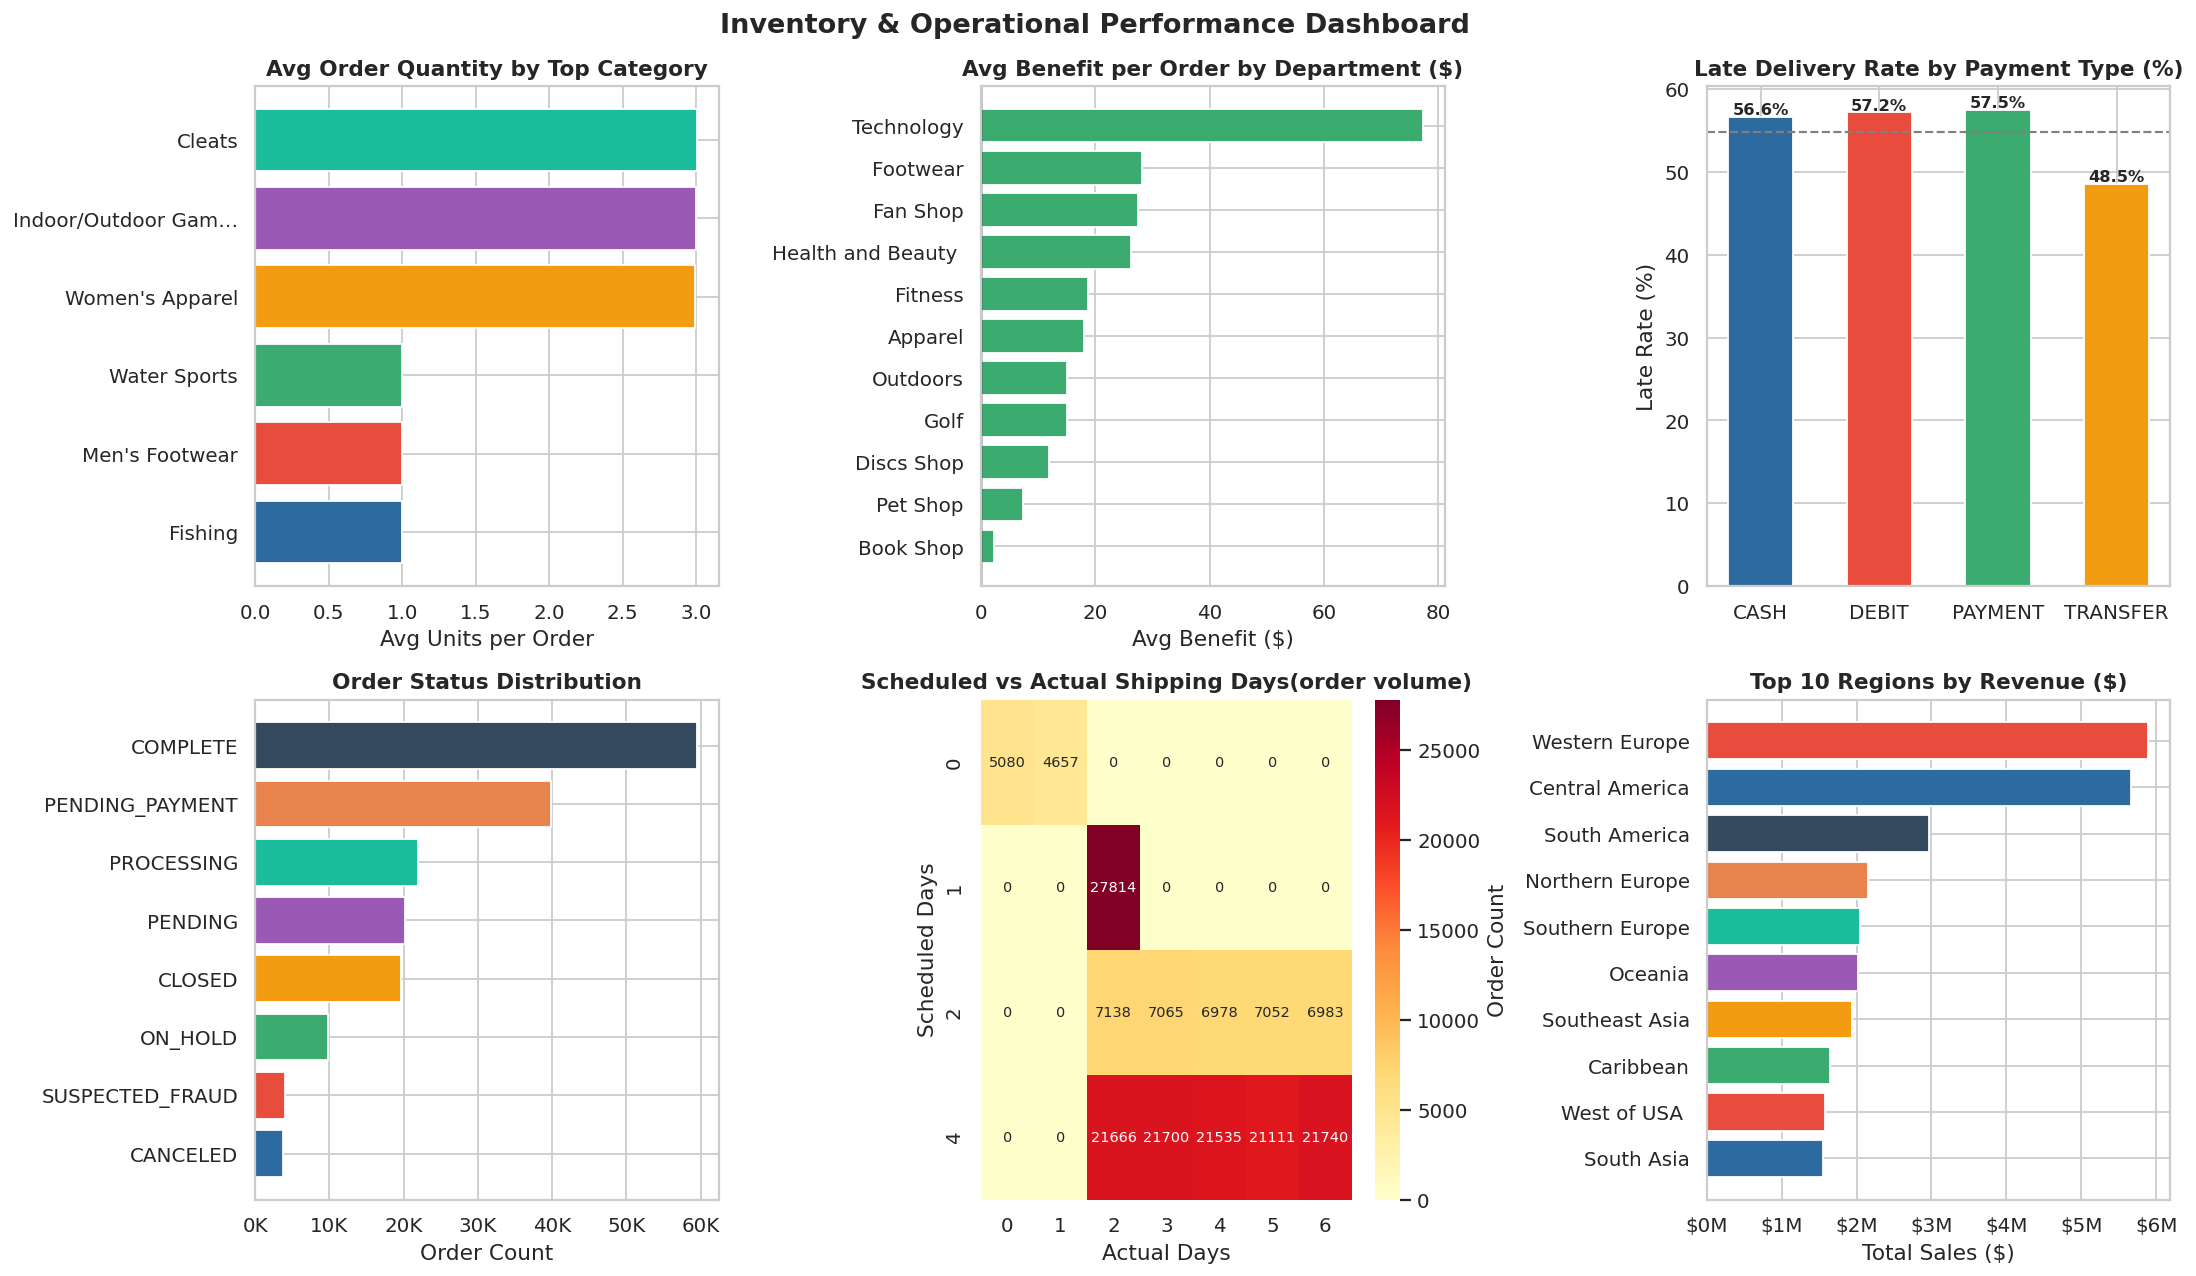

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Inventory & Operational Performance Dashboard', fontsize=15, fontweight='bold')

# Order quantity distribution by category
ax = axes[0,0]
top_cats = df['Category Name'].value_counts().head(6).index
cat_qty = df[df['Category Name'].isin(top_cats)].groupby(
    'Category Name')['Order Item Quantity'].mean().sort_values()
short_labels = [c[:18]+'…' if len(c)>18 else c for c in cat_qty.index]
ax.barh(short_labels, cat_qty.values, color=PALETTE[:6], edgecolor='white')
ax.set_title('Avg Order Quantity by Top Category', fontweight='bold')
ax.set_xlabel('Avg Units per Order')

# Benefit per order by department
ax = axes[0,1]
benefit = df.groupby('Department Name')['Benefit per order'].mean().sort_values(ascending=False)
bar_colors_b = ['#3BAB6F' if v > 0 else '#E74C3C' for v in benefit.values]
ax.barh(benefit.index[::-1], benefit.values[::-1], color=bar_colors_b[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Avg Benefit per Order by Department ($)', fontweight='bold')
ax.set_xlabel('Avg Benefit ($)')

# Payment type vs late delivery
ax = axes[0,2]
pay_late = df.groupby('Type')['is_late'].mean()*100
bars = ax.bar(pay_late.index, pay_late.values, color=PALETTE[:4], width=0.55, edgecolor='white')
ax.axhline(avg_late, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Late Delivery Rate by Payment Type (%)', fontweight='bold')
ax.set_ylabel('Late Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Order status breakdown
ax = axes[1,0]
status = df['Order Status'].value_counts().head(8)
bars = ax.barh(status.index[::-1], status.values[::-1], color=PALETTE[:8], edgecolor='white')
ax.set_title('Order Status Distribution', fontweight='bold')
ax.set_xlabel('Order Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Scheduled vs real shipping days heatmap
ax = axes[1,1]
sched_real = df.groupby(['Days for shipment (scheduled)',
                          'Days for shipping (real)']).size().unstack(fill_value=0)
sns.heatmap(sched_real, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax, cbar_kws={'label':'Order Count'},
            annot_kws={'size':8})
ax.set_title('Scheduled vs Actual Shipping Days(order volume)', fontweight='bold')
ax.set_xlabel('Actual Days')
ax.set_ylabel('Scheduled Days')

# Top 10 regions by revenue
ax = axes[1,2]
region_rev = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False).head(10)
ax.barh(region_rev.index[::-1], region_rev.values[::-1],
        color=PALETTE[:10], edgecolor='white')
ax.set_title('Top 10 Regions by Revenue ($)', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('inventory_ops.png', bbox_inches='tight')
plt.show()


## 9. Key Findings & Recommendations

### Supply Chain KPIs Summary
- **Late delivery rate: 54.8%** — more than half of all orders arrive late, representing a critical operational failure
- **First Class shipping has the highest late rate** — counterintuitively, premium shipping modes show worse on-time performance, suggesting a capacity/routing mismatch
- **LATAM and Pacific Asia** have the highest late delivery rates by market

### Financial Impact of Late Deliveries
- Late orders generate **lower average profit** than on-time orders — suggesting customers who receive late orders apply pressure on pricing or return goods
- **Discount rate and profit ratio are strongly negatively correlated (r = -0.85)** — excessive discounting is the single biggest margin erosion driver

### Customer Segments
| Segment | Action |
|---|---|
| **Premium High-Value** | Protect with SLA guarantees; assign dedicated account management |
| **Regular Steady** | Upsell bundles; reward with loyalty discounts |
| **Budget Discount-Seekers** | Review discount policy; apply minimum order thresholds |
| **At-Risk Low-Margin** | Audit profitability; reduce fulfilment priority; consider minimum spend |

### Operational Recommendations
1. **Audit First Class and Same Day shipping routes** — on-time performance below Standard Class is a routing/capacity issue requiring immediate investigation
2. **Implement a discount approval threshold** — orders with discount rate > 0.2 should require manager sign-off given the strong negative correlation with profit
3. **Prioritise inventory for Central America and Western Europe** — these regions drive the highest revenue and currently experience above-average late delivery rates
4. **Deploy the late delivery prediction model** at order placement — flagging high-risk orders (probability > 0.65) allows proactive rerouting before dispatch

### Model Performance
- **Best model: Gradient Boosting / Random Forest — AUC ~0.67**
- The moderate AUC reflects that late delivery is driven partly by external logistics factors (carrier delays, customs) not captured in order-level data
- Adding carrier-level and weather data as features would significantly improve predictive power
